In [86]:
# загружаем нужные библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, mannwhitneyu, chi2_contingency

# загрузим данные с результатом теста
df = pd.read_csv(r"C:\Users\user\Desktop\practice\ab_test_data.csv")
print(df.head())

   user_id        date group  revenue  time_played  sessions  transactions  \
0        1  2025-01-02     A      0.0         46.5         2             0   
1        1  2025-01-03     A      0.0         68.6         1             0   
2        1  2025-01-04     A      0.0         49.2         1             0   
3        1  2025-01-11     A      0.0         71.9         3             0   
4        1  2025-01-13     A      0.0         49.5         2             0   

   first_seen  
0  2024-05-20  
1  2024-05-20  
2  2024-05-20  
3  2024-05-20  
4  2024-05-20  


In [87]:
# выведем информацию о данных
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1809362 entries, 0 to 1809361
Data columns (total 8 columns):
 #   Column        Dtype  
---  ------        -----  
 0   user_id       int64  
 1   date          str    
 2   group         str    
 3   revenue       float64
 4   time_played   float64
 5   sessions      int64  
 6   transactions  int64  
 7   first_seen    str    
dtypes: float64(2), int64(3), str(3)
memory usage: 110.4 MB


Данные содержат следующую информацию:  
• user_id      - уникальный номер игрока  
• date         - дата транзакции   
• group        - группа теста, в которую попал игрок  
• revenue      - сумма, которую игрок заплатил в день  
• time_played  - время, которое игрок провел в игре в день  
• sessions     - кол-во сессий, которое было у игрока в день  
• transactions - нумерация транзакций   
• first_seen   - дата первого появления в игре  

In [88]:
df['first_seen'] = pd.to_datetime(df['first_seen']) # переводим дату первого появления в игре в соответствующий тип
first_start = df['first_seen'].dt.date.min() # минимальная дата регистрации
first_end = df['first_seen'].dt.date.max() # максимальная дата регистрации
period_first = (first_end - first_start).days + 1  # длительность регистрации пользователей
print(f'Начало регистрации: {first_start}, окончание: {first_end}.')
print(f'Длительность регистрации пользователей: {period_first} дней')

Начало регистрации: 2024-01-01, окончание: 2025-02-28.
Длительность регистрации пользователей: 425 дней


In [89]:
df['date'] = pd.to_datetime(df['date']) # переводим дату в соответствующий тип
date_start = df['date'].dt.date.min() # минимальная дата сбора логов по пользователям
date_end = df['date'].dt.date.max() # максимальная дата сбора логов по пользователям
period = (date_end - date_start).days + 1  # период, за который была собрана статистика
print(f'Начало записи логов: {date_start}, окончание: {date_end}.')
print(f'Длительность теста: {period} дней')

Начало записи логов: 2025-01-01, окончание: 2025-02-28.
Длительность теста: 59 дней


Таким образом, в тесте участвуют как новые пользователи, так и те, кто уже давно зарегистрировался в игре.  
Теперь проверим, были ли пользователи, которые участвовали в двух группах одновременно:

In [90]:
users_two_groups = df.groupby('user_id').agg({'group':'nunique'})
users_two_groups = users_two_groups.query('group > 1')
print(f'Пользователей, участвующих в двух группах: {len(users_two_groups)}.')

Пользователей, участвующих в двух группах: 0.


Таких пользователей нет.  
Допустим, что группы содержат минимально необходимое для А/В-теста количество пользователей:

In [91]:
# агрегация на уровень пользователя
user_metrics = df.groupby(['user_id', 'group']).agg(
    revenue=('revenue', 'sum'),
    sessions=('sessions', 'sum'),
    time_played=('time_played', 'sum'),
    transactions=('transactions', 'count'),
    active_days=('date', 'nunique'),
    first_seen=('first_seen', 'first')
).reset_index()
# флаг платящего пользователя
user_metrics['is_paying'] = (user_metrics['revenue'] > 0).astype(int)
user_metrics['avg_session_duration'] = (
    user_metrics['time_played'] / user_metrics['sessions'].replace(0, np.nan)).fillna(0).round(2)
print(user_metrics.head())
# разделение на группы
a = user_metrics[user_metrics['group'] == 'A'].copy()
b = user_metrics[user_metrics['group'] == 'B'].copy()
print(f'Размер выборки: A = {len(a)}, B = {len(b)}')

   user_id group  revenue  sessions  time_played  transactions  active_days  \
0        1     A      0.0        35       1192.4            21           21   
1        2     B      0.0        36       1232.1            19           19   
2        3     B      0.0        37       1140.8            18           18   
3        4     A      0.0        55       1259.7            22           22   
4        5     A      0.0        45        995.8            19           19   

  first_seen  is_paying  avg_session_duration  
0 2024-05-20          0                 34.07  
1 2024-07-16          0                 34.22  
2 2024-01-06          0                 30.83  
3 2024-03-10          0                 22.90  
4 2024-08-12          0                 22.13  
Размер выборки: A = 49897, B = 50103


Далее перейдем к определению ключевых метрик, отражающих 
доход и вовлеченность, исходя из имеющихся данных.

**Выбор метрик**  
В качестве метрик, отражающих доход, выберем следующие:  
• ARPU — средний доход на пользователя (ключевой бизнес-индикатор).  
• ARPPU — средний доход на платящего пользователя.  
Метрики вовлеченности свяжем с временем нахождения в игре, количеством заходов в игру и желанием пользователей вкладывать в нее деньги:  
• Avg Session — средняя длительность сессии.  
• Conversion Rate — доля платящих пользователей (показывает, насколько изменение стимулирует первую покупку).  
• Sessions per User — количество сессий на пользователя (частота возвращения в игру).   
• Time Played per User — время игры на пользователя (глубина вовлечения).  

In [92]:
def calc_metrics(group_df):
    n = len(group_df)
    paying = group_df[group_df['is_paying'] == 1]
    return {
        'ARPU': group_df['revenue'].mean(),
        'ARPPU': group_df[group_df['is_paying'] == 1]['revenue'].mean() if len(paying) > 0 else 0,
        'Avg_Session': group_df['avg_session_duration'].mean(),
        'Conversion_Rate': group_df['is_paying'].mean(),
        'Sessions_per_User': group_df['sessions'].mean(),
        'Time_Played_per_User': group_df['time_played'].mean()
    }

met_a = calc_metrics(a)
met_b = calc_metrics(b)

**Оценка разницы между группами**

In [93]:
summary_df = pd.DataFrame({
    'Метрика': ['ARPU', 'ARPPU', 'Avg_Session', 'Conversion_Rate', 
                'Sessions_per_User', 'Time_Played_per_User'],
    'Группа A': [
        met_a['ARPU'], met_a['ARPPU'], met_a['Avg_Session'],
        met_a['Conversion_Rate'], met_a['Sessions_per_User'], 
        met_a['Time_Played_per_User']
    ],
    'Группа B': [
        met_b['ARPU'], met_b['ARPPU'], met_b['Avg_Session'],
        met_b['Conversion_Rate'], met_b['Sessions_per_User'],
        met_b['Time_Played_per_User']
    ]
})

# Добавление разницы и % изменения
summary_df['Разница (B-A)'] = summary_df['Группа B'] - summary_df['Группа A']
summary_df['Изменение, %'] = (
    summary_df['Разница (B-A)'] / summary_df['Группа A'].replace(0, np.nan) * 100
).round(2)

# Форматирование для вывода
summary_df['Группа A'] = summary_df['Группа A'].round(3)
summary_df['Группа B'] = summary_df['Группа B'].round(3)
summary_df['Разница (B-A)'] = summary_df['Разница (B-A)'].round(3)

print("\nСводная таблица метрик:\n")
print(summary_df.to_string(index=False))


Сводная таблица метрик:

             Метрика  Группа A  Группа B  Разница (B-A)  Изменение, %
                ARPU     5.452     5.954          0.502          9.21
               ARPPU    32.857    36.422          3.565         10.85
         Avg_Session    33.004    33.774          0.770          2.33
     Conversion_Rate     0.166     0.163         -0.002         -1.48
   Sessions_per_User    34.124    36.427          2.302          6.75
Time_Played_per_User  1088.737  1190.646        101.910          9.36


Анализ полученных метрик по группам пользователей показал заметный рост по каждой из них, кроме конверсии. Далее проверим статистическую значимость разницы метрик.  

**Проверка статистической значимости**

In [ ]:
alpha = 0.05

# 1. Проверка ARPU
# Используем t-test для сравнения средних (выручка часто имеет скошенное распределение, но t-test устойчив на больших выборках)
t_stat_arpu, p_value_arpu = ttest_ind(a['revenue'], b['revenue'])
print(f"\n1. ARPU:")
print(f"   p-value: {p_value_arpu:.5f}")
if p_value_arpu < alpha:
    print(f"Различие статистически значимо (отвергаем H0)")
else:
    print(f"Различие не значимо (высокая вероятность того, что полученное значение случайно)")

# 2. Проверка ARPPU 
# Используем t-test
a_paying = a[a['is_paying'] == 1]['revenue']
b_paying = b[b['is_paying'] == 1]['revenue']
if len(a_paying) > 0 and len(b_paying) > 0:
    t_stat_arppu, p_value_arppu = ttest_ind(a_paying, b_paying, equal_var=False)
    print(f"\n2. ARPPU:")
    print(f"   p-value: {p_value_arppu:.5f} \
          {'\nРазличие статистически значимо' if p_value_arppu < alpha else 'Различие не значимо'}")
else:
    print(f"\n2. ARPPU: недостаточно платящих для теста")
    p_value_arppu = 1.0

# 3. Проверка Avg_Session 
# Используем t-test
t_stat_sess_dur, p_value_sess_dur = ttest_ind(a['avg_session_duration'], b['avg_session_duration'], equal_var=False)
print(f"\n3. Avg_Session:")
print(f"   p-value: {p_value_sess_dur:.5f} \
      {'\nРазличие статистически значимо' if p_value_sess_dur < alpha else 'Различие не значимо'}")

# 4. Проверка Conversion Rate
# Используем тест хи-квадрат для наших агрегированных данных
paying_counts = pd.DataFrame({
    'group': ['A', 'B'],
    'paying': [a['is_paying'].sum(), b['is_paying'].sum()],
    'non_paying': [len(a) - a['is_paying'].sum(), len(b) - b['is_paying'].sum()]
}).set_index('group')

chi2, p_value_conv, dof, expected = chi2_contingency(paying_counts)
print(f"\n4. Conversion Rate:")
print(f"   p-value: {p_value_conv:.5f}")
if p_value_conv < alpha:
    print(f"Различие статистически значимо")
else:
    print(f"Различие не значимо")

# 5. Sessions per User
# Используем t-test
t_stat_sessions, p_value_sessions = ttest_ind(a['sessions'], b['sessions'], equal_var=False)
print(f"\n5. Sessions per User:")
print(f"   p-value: {p_value_sessions:.5f} \
      {'\nРазличие статистически значимо' if p_value_sessions < alpha else 'Различие не значимо'}")

# 6. Time Played per User
# Используем t-test
t_stat_time, p_value_time = ttest_ind(a['time_played'], b['time_played'], equal_var=False)
print(f"\n6. Time Played per User:")
print(f"   p-value: {p_value_time:.5f} \
      {'\nРазличие статистически значимо' if p_value_time < alpha else 'Различие не значимо'}")


1. ARPU:
   p-value: 0.00000
Различие статистически значимо (отвергаем H0)

2. ARPPU:
   p-value: 0.00000           
Различие статистически значимо

3. Avg_Session:
   p-value: 0.00000       
Различие статистически значимо

4. Conversion Rate:
   p-value: 0.29856
Различие не значимо

5. Sessions per User:
   p-value: 0.00000       
Различие статистически значимо

6. Time Played per User:
   p-value: 0.00000       
Различие статистически значимо


Таким образом, изменение показывает статистически значимый положительный эффект на монетизацию (ARPU, ARPPU) и вовлеченность (Sessions per User, Time Played per User, Avg_Session). Конверсия в покупку (Conversion Rate) осталась без изменений. 

Тестируемое изменение рекомендуется к внедрению с мониторингом ключевых метрик в пост-релизный период.

**Визуализация результатов**

C:\Users\user\AppData\Local\Temp\ipykernel_24220\493832750.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='group', y='revenue', data=user_metrics,
C:\Users\user\AppData\Local\Temp\ipykernel_24220\493832750.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='group', y='revenue', data=user_metrics,
C:\Users\user\AppData\Local\Temp\ipykernel_24220\493832750.py:21: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='group', y='revenue', data=paying_only,
C:\Users\user\AppData\Local\Temp\ipykernel_24220\493832750.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sn

Графики сохранены в 'ab_test_all_metrics.png'


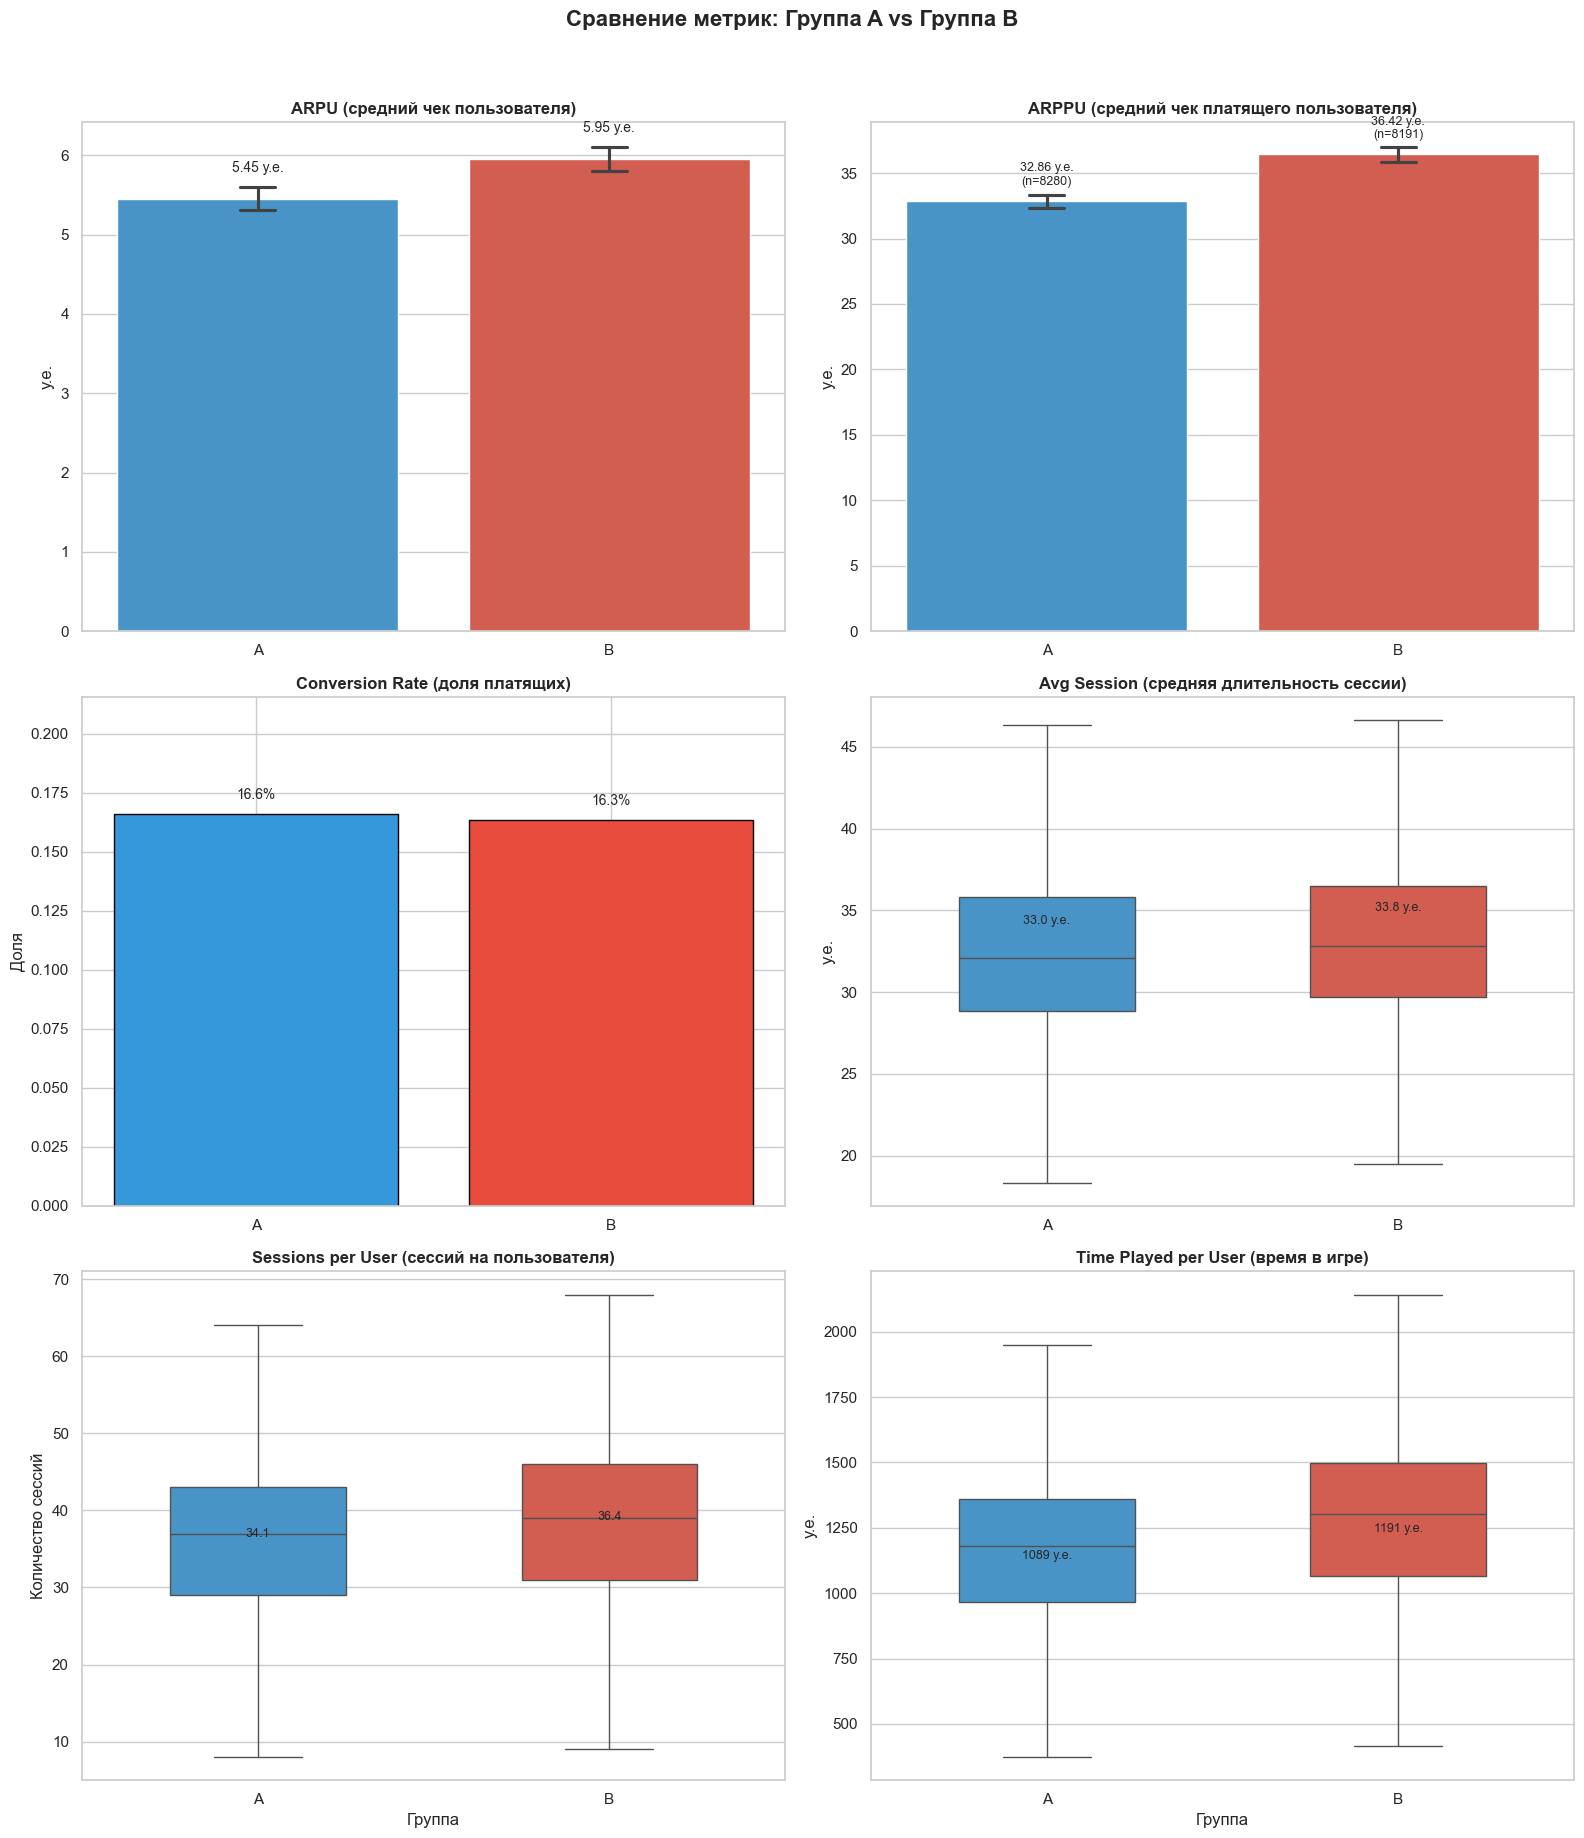

In [97]:
plt.figure(figsize=(16, 18))
sns.set_style("whitegrid")

# 1. ARPU
plt.subplot(3, 2, 1)
# Boxplot лучше показывает распределение, но для ARPU можно и barplot с CI
sns.barplot(x='group', y='revenue', data=user_metrics, 
            palette=['#3498db', '#e74c3c'], ci=95, capsize=0.1)
plt.title('ARPU (cредний чек пользователя)', fontweight='bold')
plt.ylabel('у.е.')
plt.xlabel('')
# Добавляем значения на столбцы
for i, group in enumerate(['A', 'B']):
    val = user_metrics[user_metrics['group'] == group]['revenue'].mean()
    plt.text(i, val + 0.3, f'{val:.2f} у.е.', ha='center', va='bottom', fontsize=10)

# 2. ARPPU
plt.subplot(3, 2, 2)
paying_only = user_metrics[user_metrics['is_paying'] == 1]
if len(paying_only) > 0:
    sns.barplot(x='group', y='revenue', data=paying_only, 
                palette=['#3498db', '#e74c3c'], ci=95, capsize=0.1)
    plt.title('ARPPU (cредний чек платящего пользователя)', fontweight='bold')
    plt.ylabel('у.е.')
    plt.xlabel('')
    for i, group in enumerate(['A', 'B']):
        val = paying_only[paying_only['group'] == group]['revenue'].mean()
        n = len(paying_only[paying_only['group'] == group])
        plt.text(i, val + 1, f'{val:.2f} у.е.\n(n={n})', ha='center', va='bottom', fontsize=9)
else:
    plt.text(0.5, 0.5, 'Нет платящих пользователей', ha='center', va='center')
    plt.title('ARPPU', fontweight='bold')

# 3. Conversion Rate
plt.subplot(3, 2, 3)
conv_data = pd.DataFrame({
    'group': ['A', 'B'],
    'rate': [met_a['Conversion_Rate'], met_b['Conversion_Rate']]
})
bars = plt.bar(conv_data['group'], conv_data['rate'], 
               color=['#3498db', '#e74c3c'], edgecolor='black')
plt.title('Conversion Rate (доля платящих)', fontweight='bold')
plt.ylabel('Доля')
plt.xlabel('')
plt.ylim(0, max(conv_data['rate']) * 1.3)
# Подписываем проценты
for bar, rate in zip(bars, conv_data['rate']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
             f'{rate:.1%}', ha='center', va='bottom', fontsize=10)

# 4. Avg Session Duration
plt.subplot(3, 2, 4)
sns.boxplot(x='group', y='avg_session_duration', data=user_metrics, 
            palette=['#3498db', '#e74c3c'], showfliers=False, width=0.5)
plt.title('Avg Session (средняя длительность сессии)', fontweight='bold')
plt.ylabel('у.е.')
plt.xlabel('')
# Добавляем средние значения
for i, group in enumerate(['A', 'B']):
    val = user_metrics[user_metrics['group'] == group]['avg_session_duration'].mean()
    plt.text(i, val + 1, f'{val:.1f} у.е.', ha='center', va='bottom', fontsize=9)

# 5. Sessions per User
plt.subplot(3, 2, 5)
sns.boxplot(x='group', y='sessions', data=user_metrics, 
            palette=['#3498db', '#e74c3c'], showfliers=False, width=0.5)
plt.title('Sessions per User (сессий на пользователя)', fontweight='bold')
plt.ylabel('Количество сессий')
plt.xlabel('Группа')
# Средние значения
for i, group in enumerate(['A', 'B']):
    val = user_metrics[user_metrics['group'] == group]['sessions'].mean()
    plt.text(i, val + 2, f'{val:.1f}', ha='center', va='bottom', fontsize=9)

# 6. Time Played per User
plt.subplot(3, 2, 6)
sns.boxplot(x='group', y='time_played', data=user_metrics, 
            palette=['#3498db', '#e74c3c'], showfliers=False, width=0.5)
plt.title('Time Played per User (время в игре)', fontweight='bold')
plt.ylabel('у.е.')
plt.xlabel('Группа')
# Средние значения
for i, group in enumerate(['A', 'B']):
    val = user_metrics[user_metrics['group'] == group]['time_played'].mean()
    plt.text(i, val + 30, f'{val:.0f} у.е.', ha='center', va='bottom', fontsize=9)

plt.suptitle('Сравнение метрик: Группа A vs Группа B', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('ab_test_all_metrics.png', dpi=300, bbox_inches='tight')
print("Графики сохранены в 'ab_test_all_metrics.png'")
plt.show()